generate `low_res` image for every slide:

In [2]:
from glob import glob

tif_list = '/data1/r20user3/shared_project/Hist2Cell/data/human_lung_cell2location'
tif_list = glob(tif_list + '/*[!xlsx|ipynb|ad]')
tif_list

['/data1/r20user3/shared_project/Hist2Cell/data/human_lung_cell2location/WSA_LngSP8759313',
 '/data1/r20user3/shared_project/Hist2Cell/data/human_lung_cell2location/WSA_LngSP10193347',
 '/data1/r20user3/shared_project/Hist2Cell/data/human_lung_cell2location/WSA_LngSP8759311',
 '/data1/r20user3/shared_project/Hist2Cell/data/human_lung_cell2location/WSA_LngSP10193348',
 '/data1/r20user3/shared_project/Hist2Cell/data/human_lung_cell2location/WSA_LngSP9258468',
 '/data1/r20user3/shared_project/Hist2Cell/data/human_lung_cell2location/WSA_LngSP9258464',
 '/data1/r20user3/shared_project/Hist2Cell/data/human_lung_cell2location/WSA_LngSP9258467',
 '/data1/r20user3/shared_project/Hist2Cell/data/human_lung_cell2location/WSA_LngSP8759312',
 '/data1/r20user3/shared_project/Hist2Cell/data/human_lung_cell2location/WSA_LngSP9258463',
 '/data1/r20user3/shared_project/Hist2Cell/data/human_lung_cell2location/WSA_LngSP10193346',
 '/data1/r20user3/shared_project/Hist2Cell/data/human_lung_cell2location/WSA_

In [9]:
import os
from PIL import Image
Image.MAX_IMAGE_PIXELS = None


for slide in tif_list:
    tif_img_path = os.path.join(slide, slide.split('/')[-1] + '.tif')
    if os.path.exists(tif_img_path):
        jpg_img_path = os.path.join(slide, slide.split('/')[-1] + '.jpg')
        # 打开TIFF图像
        with Image.open(tif_img_path) as img:
            # 将图像转换为RGB模式，以防它是其他模式（比如CMYK）
            img = img.convert('RGB')
            # 保存为JPG
            img.save(jpg_img_path, 'JPEG')

In [11]:
from tqdm import tqdm

for slide in tqdm(tif_list):
    high_res_img_path = os.path.join(slide, slide.split('/')[-1] + '.jpg')
    low_res_img_path = os.path.join(slide, slide.split('/')[-1] + '_low_res.jpg')
    # 打开JPG图像
    with Image.open(high_res_img_path) as img:
        # 获取当前尺寸并计算新尺寸（四分之一）
        width, height = img.size
        new_size = (width // 4, height // 4)

        # 缩小图像
        smaller_img = img.resize(new_size, Image.ANTIALIAS)

        # 保存缩小后的图像
        smaller_img.save(low_res_img_path, 'JPEG')

  0%|          | 0/11 [00:00<?, ?it/s]/tmp/ipykernel_2999997/4042626919.py:13: DeprecationWarning: ANTIALIAS is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.LANCZOS instead.
  smaller_img = img.resize(new_size, Image.ANTIALIAS)
100%|██████████| 11/11 [02:00<00:00, 10.91s/it]


create `anndata` for `cell2location`, `hist2cell`, `stnet`, and visualize the selected cell abundances:

In [27]:
import matplotlib.pyplot as plt 
import matplotlib
from matplotlib import rcParams
rcParams['pdf.fonttype'] = 42 # enables correct plotting of text
import numpy as np
from scipy.spatial.distance import jensenshannon
import matplotlib as mpl
import joblib
import pandas as pd
import os
from anndata import AnnData
import scanpy as sc
import cv2
from glob import glob
from PIL import Image
Image.MAX_IMAGE_PIXELS = None


def create_anndata(counts, coordinates, cell_names, image):
    adata = AnnData(counts, obsm={"spatial": coordinates}, dtype=np.int64)
    adata.var_names = cell_names
    spatial_key = "spatial"
    library_id = slide
    adata.uns[spatial_key] = {library_id: {}}
    adata.uns[spatial_key][library_id]["images"] = {"lowres": image}
    adata.uns[spatial_key][library_id]["scalefactors"] = {"tissue_hires_scalef": 1, "spot_diameter_fullres": 224.0}
    
    return adata

In [35]:
case = "A50"
slide = "WSA_LngSP9258467"

cell_names = [cell[23:] for cell in list(pd.read_csv("/data1/r20user3/shared_project/Hist2Cell/data/human_lung_cell2location/WSA_LngSP8759311/cell_ratio.csv").columns)[1:]]
image = cv2.imread("/data1/r20user3/shared_project/Hist2Cell/data/human_lung_cell2location/"+slide+"/"+slide+"_low_res.jpg")

selected_cell_names = ['Ciliated', 'Basal', 'AT1', 'AT2', 'Chondrocyte']

In [36]:
save_path = "/data1/r20user3/shared_project/Hist2Cell/code/analysis/inference/humanlung/humanlung_epoch100_lr1e-4_2hop_ensemble_onlycell_"+case+"_best_cell_all_abundance_average.pkl"
pred_and_label = joblib.load(save_path)

adata_cell2location = create_anndata(counts=np.clip(pred_and_label[slide]['cell_abundance_labels'], a_min=0, a_max=None), 
                                     coordinates=pred_and_label[slide]['coords'], 
                                     cell_names=cell_names, 
                                     image=image)

adata_hist2cell = create_anndata(counts=np.clip(pred_and_label[slide]['cell_abundance_predictions'], a_min=0, a_max=None), 
                                     coordinates=pred_and_label[slide]['coords'], 
                                     cell_names=cell_names, 
                                     image=image)

In [37]:
save_path = "/data1/r20user3/shared_project/Hist2Cell/code/analysis/inference/humanlung/humanlung_epoch100_lr1e-4_densenet_onlycell_"+case+"_best_cell_all_abundance_average.pkl"
pred_and_label = joblib.load(save_path)

adata_stnet = create_anndata(counts=np.clip(pred_and_label[slide]['cell_abundance_predictions'], a_min=0, a_max=None), 
                             coordinates=pred_and_label[slide]['coords'],                             
                             cell_names=cell_names, 
                             image=image)

/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1207: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(values):


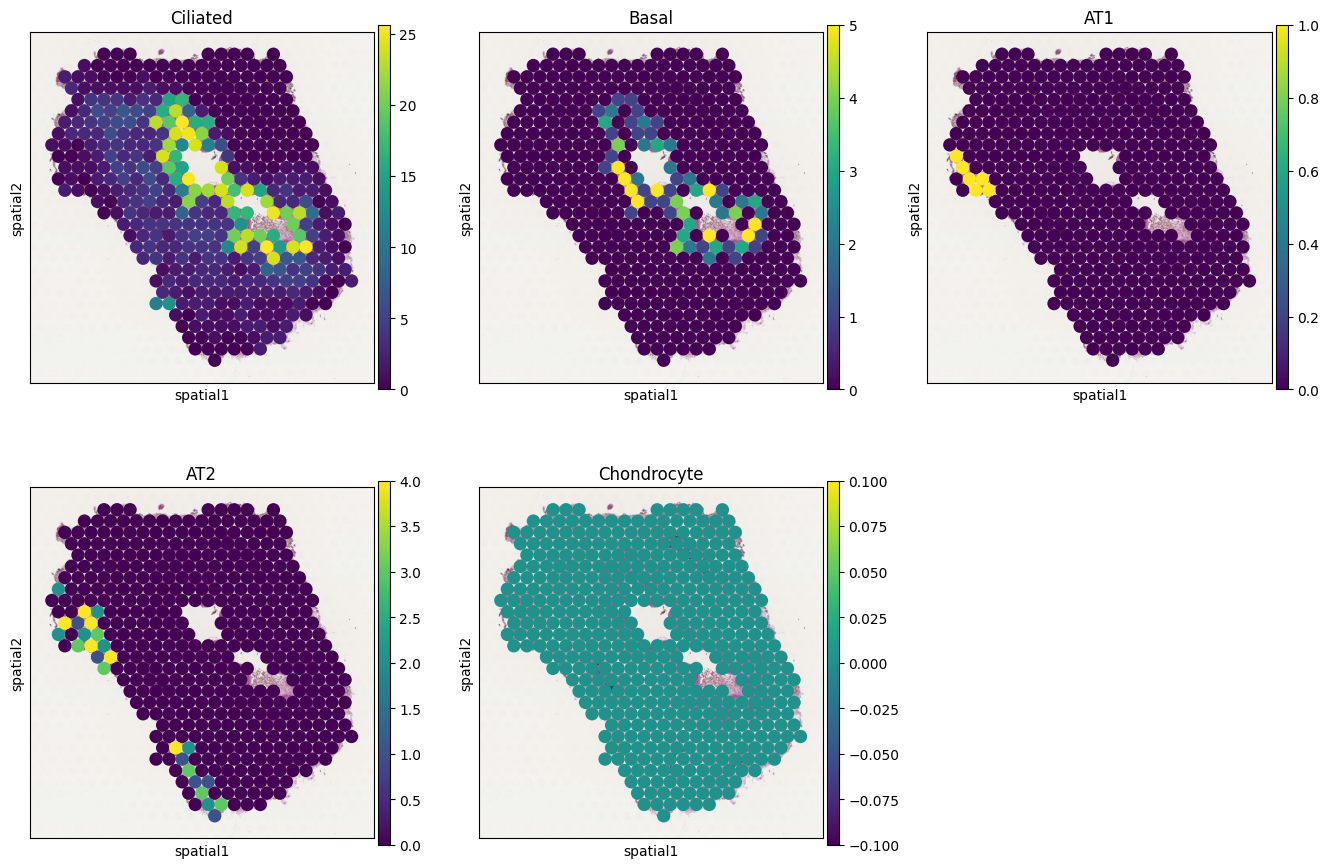

In [41]:
# with mpl.rc_context({'figure.figsize': (10, 10), "font.size": 18}):
with mpl.rc_context({'axes.facecolor':  'black', 'figure.figsize': [4.5, 5]}):
    img = sc.pl.spatial(adata_cell2location, 
                color=selected_cell_names, 
                ncols=3, 
                cmap='viridis',
                size=1.0, 
                img_key='lowres',
                # alpha_img=0.9, 
                vmin='p0.0', vmax='p99.2',
                return_fig=True,
                scale_factor=0.25,
                )

/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1207: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(values):


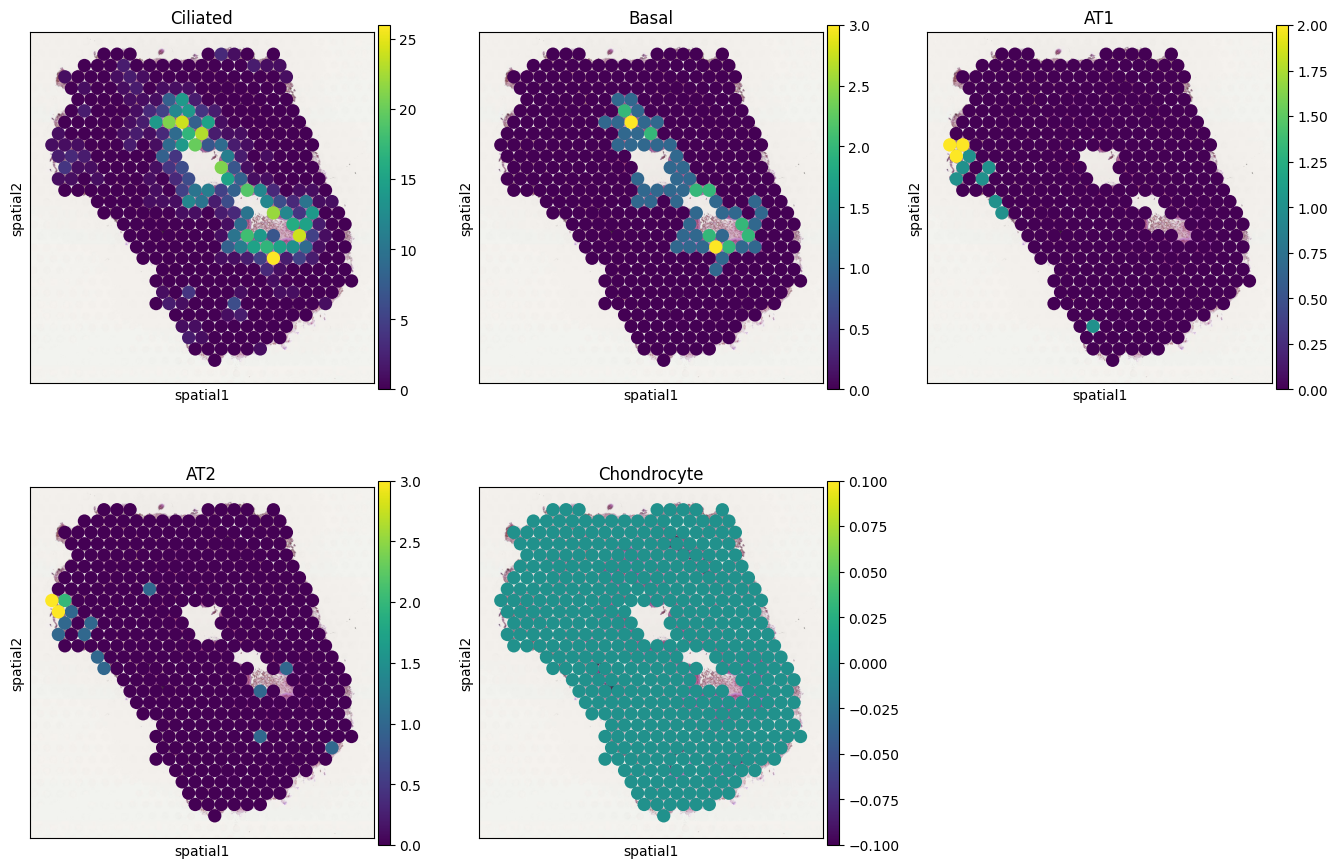

In [39]:
# with mpl.rc_context({'figure.figsize': (10, 10), "font.size": 18}):
with mpl.rc_context({'axes.facecolor':  'black', 'figure.figsize': [4.5, 5]}):
    img = sc.pl.spatial(adata_hist2cell, 
                color=selected_cell_names, 
                ncols=3, 
                cmap='viridis',
                size=1.0, 
                img_key='lowres',
                # alpha_img=0.9, 
                # vmin='p0.0', vmax='p99.2',
                return_fig=True,
                scale_factor=0.25,
                )

/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1207: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(values):


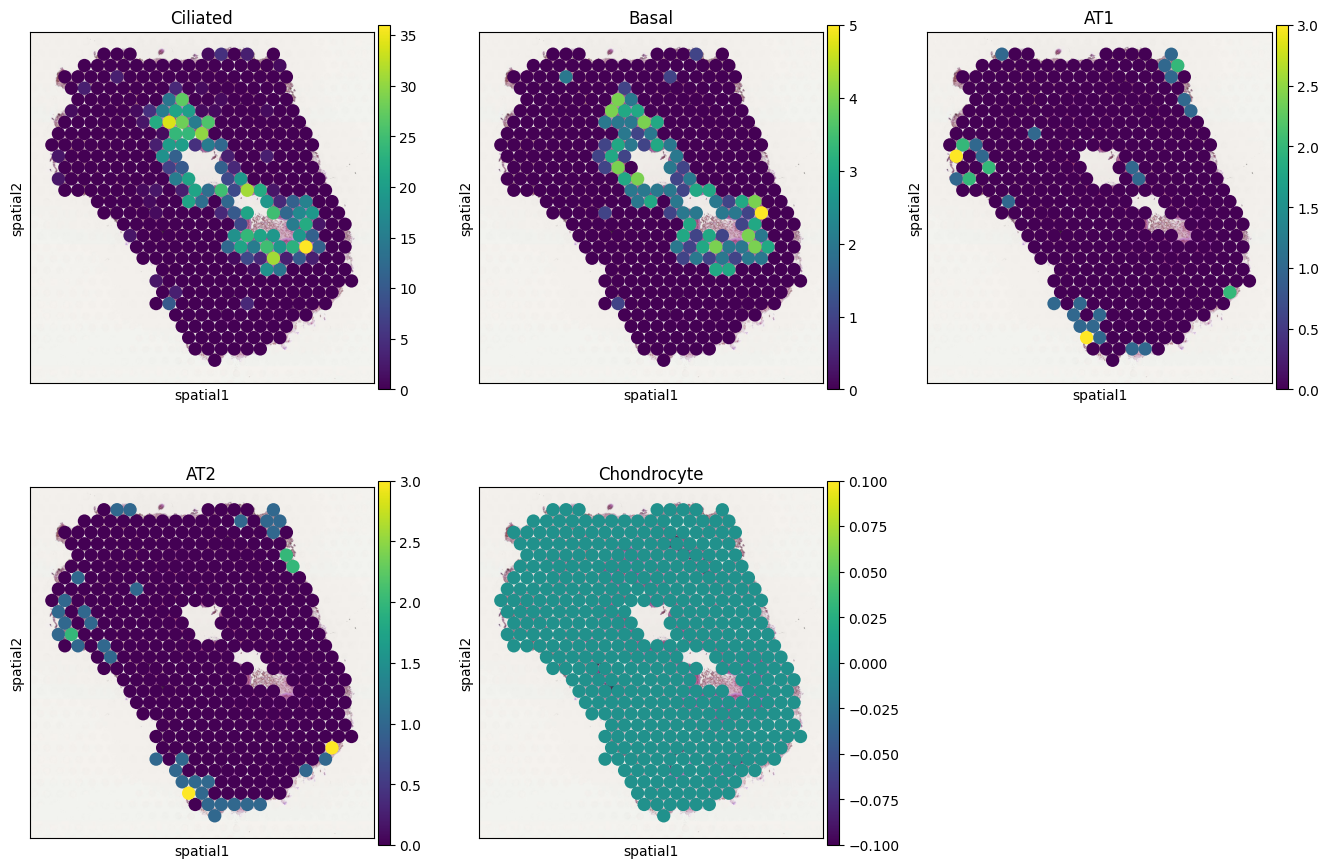

In [40]:
# with mpl.rc_context({'figure.figsize': (10, 10), "font.size": 18}):
with mpl.rc_context({'axes.facecolor':  'black', 'figure.figsize': [4.5, 5]}):
    img = sc.pl.spatial(adata_stnet, 
                color=selected_cell_names, 
                ncols=3, 
                cmap='viridis',
                size=1.0, 
                img_key='lowres',
                # alpha_img=0.9, 
                # vmin='p0.0', vmax='p99.2',
                return_fig=True,
                scale_factor=0.25,
                )